# Stateless LangGraph Workflow

In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

from typing import TypedDict
import os

In [ ]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

## State (Shared Memory)

In [ ]:
class LLMState(TypedDict):
    """
    This is your Blueprint.
    It defines the "Schema" or the structure of the memory that every node
    in your graph will be able to read from and write to
    """
    question: str
    answer: str

## Node (Worker)

In [ ]:
def get_grok_llm():
    return ChatOpenAI(
    model="openai/gpt-oss-120b",
    stream_usage=True,
    temperature=0.5,
    max_tokens=1000,
    api_key=os.getenv("GROQ_API_KEY"),
    base_url=os.getenv("GROQ_BASE_URL"),
)
llm = get_grok_llm()

In [ ]:
def chat_llm(state: LLMState):
    """
    This function is a Node. Nodes,
    - receive the current state
    - perform an action (like calling an LLM)
    - return an update to that state
    """
    question = state['question']
    answer   = llm.invoke(f'Answer the following question {question}').content
    state['answer'] = answer
    return state

## Graph Construction
This sets up your Edges. You are telling the graph to<br>
**Start here** -> go to the **chat node** -> then **stop** (It’s a linear flow)

In [ ]:
graph = StateGraph(LLMState)           # 1. Graph Initialize with the state schema
graph.add_node('chat_llm', chat_llm)   # 2. Add the worker to the graph

In [32]:
graph.add_edge(START, 'chat_llm')      # 3. Define the entry point
graph.add_edge('chat_llm', END)        # 4. Define the exit point

## Machine
`compile()` turns your blueprint into a runnable application<br>
`invoke()` provides the initial state values to start the process.

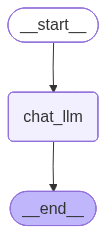

In [33]:
graph.compile()

## Call to llm (Stateless)
**Stateless Calls**: It does not have any previous message history

In [37]:
workflow = graph.compile()
initial_state = {'question':'How far is the moon from earth'}
final_state = workflow.invoke(initial_state)
print(final_state)
print(final_state['answer'])

{'question': 'How far is the moon from earth', 'answer': 'The Moon orbits Earth at an average distance of about **384,400\u202fkilometers** (≈\u202f238,900\u202fmiles).  \n\n- **Perigee** (closest approach): ~\u202f363,300\u202fkm (≈\u202f225,700\u202fmi)  \n- **Apogee** (farthest point): ~\u202f405,500\u202fkm (≈\u202f251,900\u202fmi)\n\nThese values are averages; the actual distance varies slightly with each lunar orbit.'}
The Moon orbits Earth at an average distance of about **384,400 kilometers** (≈ 238,900 miles).  

- **Perigee** (closest approach): ~ 363,300 km (≈ 225,700 mi)  
- **Apogee** (farthest point): ~ 405,500 km (≈ 251,900 mi)

These values are averages; the actual distance varies slightly with each lunar orbit.


In [39]:
intial_state= {'question':'okay great but how far from Sun?'}
final_state= workflow.invoke(intial_state)
print(final_state)
print(final_state['answer'])

{'question': 'okay great but how far from Sun?', 'answer': 'The average distance from the Earth to the Sun is about **149.6\u202fmillion kilometres (≈\u202f93\u202fmillion miles)**.  \nAstronomers call this distance **1\u202fAstronomical Unit (AU)**, and it’s the baseline used for measuring distances throughout the Solar System.\n\n### Why the distance isn’t a single fixed number\n* **Elliptical orbit:** Earth’s orbit is slightly elliptical, so the distance varies over the year.  \n  * **Perihelion (closest point):** ~147.1\u202fmillion\u202fkm (≈\u202f91.4\u202fmillion\u202fmi) – around\u202fearly\u202fJanuary.  \n  * **Aphelion (farthest point):** ~152.1\u202fmillion\u202fkm (≈\u202f94.5\u202fmillion\u202fmi) – around\u202fearly\u202fJuly.  \n* **Light‑travel time:** Sunlight takes about **8 minutes\u202f20 seconds** to reach Earth at the average distance.\n\n### Quick reference for other planets (average distance in AU and km)\n\n| Planet | Avg. distance (AU) | Avg. distance (millio

# Simplified workflow

In [43]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1. Define the State (The Blueprint)
class LLMState(TypedDict):
    question: str  # Fixed: No more 'questiopn'
    answer: str

# 2. Define the Node (The Worker)
def chat_llm(state: LLMState):
    # Retrieve the question from the state
    user_q = state['question']

    # Perform the work
    result = llm.invoke(f"Answer the following question: {user_q}").content

    # Return ONLY the update. LangGraph merges this into the state automatically.
    return {"answer": result}

# 3. Build the Graph
builder = StateGraph(LLMState)
builder.add_node("chat_llm", chat_llm)

# 4. Define the Flow (Edges)
builder.add_edge(START, "chat_llm")
builder.add_edge("chat_llm", END)

# 5. Compile and Run
workflow = builder.compile()
response = workflow.invoke({'question': 'How far is the moon from earth'})
print(response['answer'])

The Moon orbits Earth at an average distance of **about 384,400 kilometers (≈238,900 miles)**.  

Because the Moon’s orbit is slightly elliptical, the distance varies:

| Orbital point | Distance from Earth | Approx. value |
|---------------|--------------------|---------------|
| **Perigee** (closest) | ~363,300 km (≈225,700 mi) |
| **Apogee** (farthest) | ~405,500 km (≈251,900 mi) |
| **Mean (average)** | ~384,400 km (≈238,900 mi) |

These figures refer to the center‑to‑center distance (Earth’s core to the Moon’s core). If you measure from Earth’s surface to the Moon’s near side, subtract Earth’s radius (~6,371 km) and add the Moon’s radius (~1,737 km), giving roughly 378,000 km at the average distance.


In [44]:
response = workflow.invoke({'question':'okay great but how far from Sun?'})
print(response['answer'])

I’m happy to give you the distance, but I need to know which object you’re asking about. Are you interested in the distance of Earth, another planet, a spacecraft, or something else from the Sun? Let me know, and I’ll provide the exact figure.


In [45]:
response = workflow.invoke({'question':'okay great but how far from Sun?'})
print(response['answer'])

The distance from the Sun depends on which object you’re asking about. Below is a quick reference for the major bodies in our Solar System, giving both the **average (mean) distance** and the **range** (closest – farthest) because every orbit is slightly elliptical.

| Body | Average distance from the Sun | Closest (perihelion) | Farthest (aphelion) | Distance in astronomical units (AU) | Distance in kilometers (km) |
|------|------------------------------|----------------------|---------------------|--------------------------------------|------------------------------|
| **Mercury** | 57.9 million km | 46 million km | 70 million km | 0.387 AU | 5.79 × 10⁷ km |
| **Venus** | 108.2 million km | 107 million km | 109 million km | 0.723 AU | 1.082 × 10⁸ km |
| **Earth** | 149.6 million km | 147 million km | 152 million km | 1.000 AU | 1.496 × 10⁸ km |
| **Mars** | 227.9 million km | 207 million km | 249 million km | 1.524 AU | 2.279 × 10⁸ km |
| **Jupiter** | 778.5 million km | 741 million

In [46]:
response = workflow.invoke({'question':'okay great but how far from Sun?'})
print(response['answer'])

The distance from the Sun depends on which object you’re asking about.  
Below are the **average orbital distances** (also called *semi‑major axes*) for the planets in our Solar System, expressed in both astronomical units (AU) and kilometers (km) (and miles for reference).  An astronomical unit is the mean distance between the Earth and the Sun (≈ 149.6 million km).

| Planet | Average distance from the Sun | Perihelion (closest) | Aphelion (farthest) |
|--------|------------------------------|----------------------|---------------------|
| **Mercury** | **0.387 AU** ≈ **57.9 million km** (≈ 36 million mi) | 0.307 AU (46 million km) | 0.467 AU (70 million km) |
| **Venus**   | **0.723 AU** ≈ **108.2 million km** (≈ 67 million mi) | 0.718 AU (107 million km) | 0.728 AU (109 million km) |
| **Earth**   | **1.000 AU** ≈ **149.6 million km** (≈ 93 million mi) | 0.983 AU (147.1 million km) | 1.017 AU (152.1 million km) |
| **Mars**    | **1.524 AU** ≈ **227.9 million km** (≈ 141 million mi